# Week 2

In [1]:
import pandas as pd
# 1. Read merged listing dataset
import pandas as pd
df1 = pd.read_csv("CRMLSListing_merged.csv", low_memory=False)

print("=== DATA OVERVIEW ===")
print(f"Original row count: {df1.shape[0]}")
print(f"Original column count: {df1.shape[1]}")


=== DATA OVERVIEW ===
Original row count: 852963
Original column count: 85


In [2]:
# 2. Unique property types
print("\n=== UNIQUE PROPERTY TYPES ===")
property_type_counts = df1["PropertyType"].value_counts(dropna=False)
print(property_type_counts)

property_type_table = property_type_counts.reset_index()
property_type_table.columns = ["PropertyType", "Count"]


=== UNIQUE PROPERTY TYPES ===
PropertyType
Residential            540183
ResidentialLease       178041
Land                    56372
ResidentialIncome       31650
ManufacturedInPark      24531
CommercialSale          11715
CommercialLease          7736
BusinessOpportunity      2735
Name: count, dtype: int64


In [ ]:
df = pd.read_csv("CRMLSListing_residential.csv")
print("\n=== PropertyType Check ===")
display(df["PropertyType"].value_counts(dropna=False))

/var/folders/d_/gll3jlg1445_2nm3xgq_xvdc0000gn/T/ipykernel_34330/3587098974.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("CRMLSListing_residential.csv")



=== PropertyType Check ===


PropertyType
Residential    540183
Name: count, dtype: int64

(540183, 85)

In [4]:
# 4. Missing value summary
missing_summary = pd.DataFrame({
    "column": df.columns,
    "null_count": df.isnull().sum().values,
    "null_pct": (df.isnull().mean().values * 100).round(2)
})

missing_summary["flag_above_90pct_null"] = missing_summary["null_pct"] > 90
missing_summary = missing_summary.sort_values(by="null_count", ascending=False)


In [5]:
print("\n=== MISSING VALUE SUMMARY ===")
display(missing_summary)

print("\n=== COLUMNS ABOVE 90% NULL ===")
high_null_cols = missing_summary[missing_summary["flag_above_90pct_null"]]
display(high_null_cols)


=== MISSING VALUE SUMMARY ===


,column,null_count,null_pct,flag_above_90pct_null
28,TaxAnnualAmount,540183,100.0,True
64,CoveredSpaces,540183,100.0,True
50,TaxYear,540183,100.0,True
60,BusinessType,540183,100.0,True
25,AboveGradeFinishedArea,540183,100.0,True
...,...,...,...,...
14,ListOfficeName,0,0.0,False
13,DaysOnMarket,0,0.0,False
12,ListPrice,0,0.0,False
10,PropertyType,0,0.0,False



=== COLUMNS ABOVE 90% NULL ===


,column,null_count,null_pct,flag_above_90pct_null
28,TaxAnnualAmount,540183,100.00,True
64,CoveredSpaces,540183,100.00,True
50,TaxYear,540183,100.00,True
60,BusinessType,540183,100.00,True
25,AboveGradeFinishedArea,540183,100.00,True
23,FireplacesTotal,540183,100.00,True
82,MiddleOrJuniorSchoolDistrict,540183,100.00,True
55,ElementarySchoolDistrict,540183,100.00,True
59,BelowGradeFinishedArea,537154,99.44,True
56,CoBuyerAgentFirstName,525755,97.33,True


In [6]:
# 5. Numeric distribution summary
target_numeric_cols = ["ListPrice", "LivingArea", "DaysOnMarket"]

summary_rows = []

for col in target_numeric_cols:
    if col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        summary_rows.append({
            "column": col,
            "count_non_null": s.notna().sum(),
            "min": s.min(),
            "p5": s.quantile(0.05),
            "p25": s.quantile(0.25),
            "median": s.median(),
            "mean": s.mean(),
            "p75": s.quantile(0.75),
            "p95": s.quantile(0.95),
            "max": s.max()
        })
    else:
        summary_rows.append({
            "column": col,
            "count_non_null": None,
            "min": None,
            "p5": None,
            "p25": None,
            "median": None,
            "mean": None,
            "p75": None,
            "p95": None,
            "max": None
        })

numeric_summary = pd.DataFrame(summary_rows)

print("\n=== NUMERIC DISTRIBUTION SUMMARY ===")
display(numeric_summary)


=== NUMERIC DISTRIBUTION SUMMARY ===


,column,count_non_null,min,p5,p25,median,mean,p75,p95,max
0,ListPrice,540183,100.0,345000.0,580000.0,840000.0,1.312997e+06,1375000.0,3450000.0,195000000.0
1,LivingArea,539627,0.0,816.0,1247.0,1669.0,1.980059e+03,2300.0,3868.0,17021321.0
2,DaysOnMarket,540183,-58.0,0.0,5.0,11.0,1.953990e+01,23.0,71.0,731.0


The numeric distribution summary provides key statistics for important variables such as ListPrice, LivingArea, and DaysOnMarket.

For ListPrice, the median is $840,000, while the mean is significantly higher at approximately $1.31 million, indicating a right-skewed distribution. The very large maximum value suggests the presence of extreme high-price outliers.

For LivingArea, the median is 1,669 square feet, with a mean of about 1,980, showing a relatively moderate spread but still slightly right-skewed due to larger properties. The maximum value appears unusually high, which may indicate potential data errors or outliers.

For DaysOnMarket, the median is 11 days, while the mean is around 19.5 days, suggesting that most properties sell quickly, but some remain on the market much longer. The presence of a negative minimum value (-58) indicates possible data quality issues that should be investigated and cleaned.

 Questions
 
●	What is the Residential vs. other property type share? 

Residential properties account for approximately 63.3% of the dataset, while non-residential properties make up about 36.7%.

●	What are the median and average close prices?
 
The average close price is $1,202,136, while the median close price is $855,000.

In [7]:
mean_price = df["ClosePrice"].mean()
median_price = df["ClosePrice"].median()

print("Average Close Price:", round(mean_price, 2))
print("Median Close Price:", round(median_price, 2))

Average Close Price: 1202136.39
Median Close Price: 855000.0


●	What does the Days on Market distribution look like?

In [8]:
print(df["DaysOnMarket"].describe())

count    540183.000000
mean         19.539904
std          26.771154
min         -58.000000
25%           5.000000
50%          11.000000
75%          23.000000
max         731.000000
Name: DaysOnMarket, dtype: float64


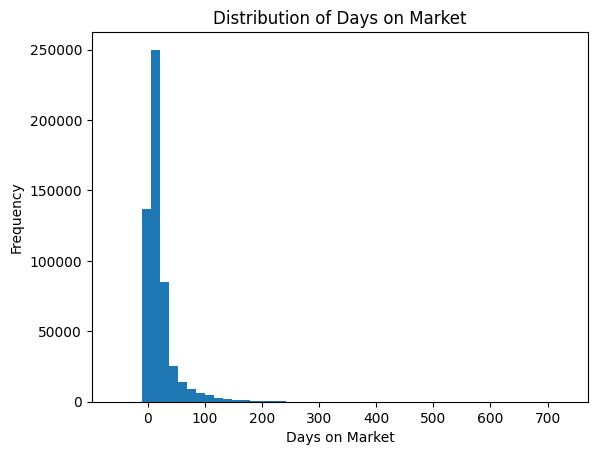

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["DaysOnMarket"], bins=50)
plt.xlabel("Days on Market")
plt.ylabel("Frequency")
plt.title("Distribution of Days on Market")
plt.show()

Days on Market is right-skewed, with most homes selling quickly and a few taking much longer. Most listings are concentrated within the first 50 days, while a few outliers extend beyond several hundred days.

●	What percentage of homes sold above vs. below list price? 

In [10]:

# Remove missing values
# =========================
df_valid = df.dropna(subset=["ClosePrice", "ListPrice"])


# Above / Below / Equal
# =========================
above = (df_valid["ClosePrice"] > df_valid["ListPrice"]).sum()
below = (df_valid["ClosePrice"] < df_valid["ListPrice"]).sum()
equal = (df_valid["ClosePrice"] == df_valid["ListPrice"]).sum()

total = len(df_valid)

print("=== Price Comparison ===")
print(f"Above List Price (%): {round(above / total * 100, 2)}")
print(f"Below List Price (%): {round(below / total * 100, 2)}")
print(f"Equal to List Price (%): {round(equal / total * 100, 2)}")

print(f"\nCheck total (%): {round((above + below + equal) / total * 100, 2)}")

=== Price Comparison ===
Above List Price (%): 43.97
Below List Price (%): 37.44
Equal to List Price (%): 18.59

Check total (%): 100.0


Approximately 44% of homes sold above the list price, 37% sold below, and about 19% sold exactly at the list price.

●	Are there any apparent date consistency issues (e.g., close date before listing date)? 

In [11]:
df["CloseDate_dt"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df["ListingDate_dt"] = pd.to_datetime(df["ListingContractDate"], errors="coerce")
df["PurchaseDate_dt"] = pd.to_datetime(df["PurchaseContractDate"], errors="coerce")

In [12]:
close_before_list = (
    df.dropna(subset=["CloseDate_dt", "ListingDate_dt"])["CloseDate_dt"]
    < df.dropna(subset=["CloseDate_dt", "ListingDate_dt"])["ListingDate_dt"]
).sum()

purchase_before_list = (
    df.dropna(subset=["PurchaseDate_dt", "ListingDate_dt"])["PurchaseDate_dt"]
    < df.dropna(subset=["PurchaseDate_dt", "ListingDate_dt"])["ListingDate_dt"]
).sum()

close_before_purchase = (
    df.dropna(subset=["CloseDate_dt", "PurchaseDate_dt"])["CloseDate_dt"]
    < df.dropna(subset=["CloseDate_dt", "PurchaseDate_dt"])["PurchaseDate_dt"]
).sum()


In [13]:
print("=== Date Consistency Issues ===")
print(f"Close date before listing date: {close_before_list}")
print(f"Purchase date before listing date: {purchase_before_list}")
print(f"Close date before purchase date: {close_before_purchase}")

=== Date Consistency Issues ===
Close date before listing date: 72
Purchase date before listing date: 271
Close date before purchase date: 265


Yes, a small number of date consistency issues are present in the dataset. Specifically, 72 records show a close date before the listing date, 271 records show a purchase date before the listing date, and 265 records show a close date before the purchase date. These sequences are logically inconsistent and likely result from data entry errors. However, the number of such cases is very small relative to the overall dataset, and they can be addressed during data cleaning.

●	Which counties have the highest median prices? 

In [14]:
median_price_by_county = (
    df.groupby("CountyOrParish")["ClosePrice"]
    .median()
    .sort_values(ascending=False)
)

print(median_price_by_county.head(10))

CountyOrParish
San Mateo        1751000.0
Santa Clara      1640000.0
Marin            1341000.0
San Francisco    1250000.0
Santa Cruz       1220000.0
Alameda          1185000.0
Orange           1175000.0
Los Angeles       916000.0
Monterey          910000.0
San Diego         900000.0
Name: ClosePrice, dtype: float64
